# Facial Recognition using Pytorch

Convolutional Neural Network (CNN) and Residual Neural Network (ResNet)

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount="True")

Mounted at /content/gdrive


In [ ]:
!pip install facenet-pytorch # May have to reset sesion and run everything again

In [ ]:
# Libraries
from facenet_pytorch import MTCNN, InceptionResnetV1, fixed_image_standardization, training, extract_face
import torch
from torch.utils.data import DataLoader, SubsetRandomSampler, SequentialSampler
from torchvision import datasets, transforms
import numpy as np
import os
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import cv2
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import itertools
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
from plotly import tools
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.vgg16 import VGG16, preprocess_input
from keras import layers
from keras.models import Model, Sequential
from keras.optimizers import Adam, RMSprop
from keras.callbacks import EarlyStopping
init_notebook_mode(connected=True)
RANDOM_SEED = 123

In [ ]:
def load_data(dir_path, IMG_SIZE):

    X = []
    y = []
    i = 0
    labels = dict()
    for path in tqdm(sorted(os.listdir(dir_path))):
        if not path.startswith('.'):
            labels[i] = path
            for file in os.listdir(dir_path + path):
                if not file.startswith('.'):
                    img = cv2.imread(dir_path + path + '/' + file)
                    img = img.astype('float32') / 255
                    resized = cv2.resize(img, IMG_SIZE, interpolation = cv2.INTER_AREA)
                    X.append(resized)
                    y.append(i)
            i += 1
    X = np.array(X)
    y = np.array(y)
    print(f'{len(X)} images loaded from {dir_path} directory.')
    return X, y, labels

In [ ]:
IMG_SIZE= (250, 250)

In [ ]:
Train = "/content/gdrive/My Drive/Masters/Train/"
X_train, y_train, train_labels = load_data(Train, IMG_SIZE)

100%|██████████| 5/5 [01:19<00:00, 15.87s/it]


418 images loaded from /content/gdrive/My Drive/Masters/Train/ directory.


In [ ]:
Test = "/content/gdrive/My Drive/Masters/Test/"
X_test, y_test, test_labels = load_data(Test,IMG_SIZE)

100%|██████████| 5/5 [00:31<00:00,  6.39s/it]

104 images loaded from /content/gdrive/My Drive/Masters/Test/ directory.


# Convolutional Neural Network (CNN)

A basic implementation of a CNN for image classification tasks, and the corresponding images show the model's loss and accuracy during training and validation.

In [ ]:
# initialize sequential network
from keras.models import Sequential
# include convolutional layers
from keras.layers import Conv2D
# Pooling layers
from keras.layers import MaxPooling2D
# flatten layers into single vector
from keras.layers import Flatten
from keras.layers import Dense

In [ ]:
model = Sequential()

# First layer applies 32 convolutional filters of size 3x3 to the input image, with a ReLU activation function
model.add(Conv2D(32, (3, 3), input_shape = (250, 250, 3), activation = 'relu'))

# The MaxPooling2D layer with a pool size of (2, 2) reduces the spatial dimensions of the feature maps
model.add(MaxPooling2D(pool_size = (2, 2)))

#The Flatten layer converts the 2D matrices into a 1D vector
model.add(Flatten())

# The Dense layer with 128 units and a ReLU activation function
model.add(Dense(units = 128, activation = 'relu'))

# The output layer with 5 units (one for each class) and a softmax activation function
model.add(Dense(units = 5, activation = 'softmax'))

model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [ ]:
def deep_model(model, X_train, Y_train, X_val, Y_val, epochs, batch_size):
    history = model.fit(
        X_train,
        Y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, Y_val),
        verbose=1,
        steps_per_epoch = 288,
        validation_steps = 72
        )

    return history

In [ ]:
from tensorflow.keras.utils import to_categorical

Y_train = to_categorical(y_train, num_classes=5) # 80% split
Y_train.shape

(418, 5)

In [ ]:
Y_test = to_categorical(y_test, num_classes=5) # 20% split
Y_test.shape

(104, 5)

In [ ]:
history = deep_model(model, X_train, Y_train, X_test, Y_test, epochs = 14, batch_size = 32) #runtime < 15 mins

Epoch 1/14
 14/288 ━━━━━━━━━━━━━━━━━━━━ 13:01 3s/step - accuracy: 0.3273 - loss: 23.5426

/usr/lib/python3.10/contextlib.py:153: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.



288/288 ━━━━━━━━━━━━━━━━━━━━ 47s 137ms/step - accuracy: 0.3983 - loss: 17.8024 - val_accuracy: 0.5096 - val_loss: 4.0220
Epoch 2/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 82s 149ms/step - accuracy: 0.5541 - loss: 2.1739 - val_accuracy: 0.3077 - val_loss: 1.6125
Epoch 3/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 81s 146ms/step - accuracy: 0.7017 - loss: 0.9571 - val_accuracy: 0.5577 - val_loss: 1.2402
Epoch 4/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 81s 141ms/step - accuracy: 0.8991 - loss: 0.4212 - val_accuracy: 0.6154 - val_loss: 1.0154
Epoch 5/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 79s 131ms/step - accuracy: 0.9857 - loss: 0.1150 - val_accuracy: 0.6827 - val_loss: 0.8657
Epoch 6/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.9974 - loss: 0.0343 - val_accuracy: 0.7115 - val_loss: 0.8090
Epoch 7/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 0.7212 - val_loss: 0.8011
Epoch 8/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 42s 130ms/step - accuracy: 1.0000 - loss: 0.0021 - va

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

def plot_metrics(history):
    # Plot training & validation accuracy values
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

    # Plot training & validation loss values
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

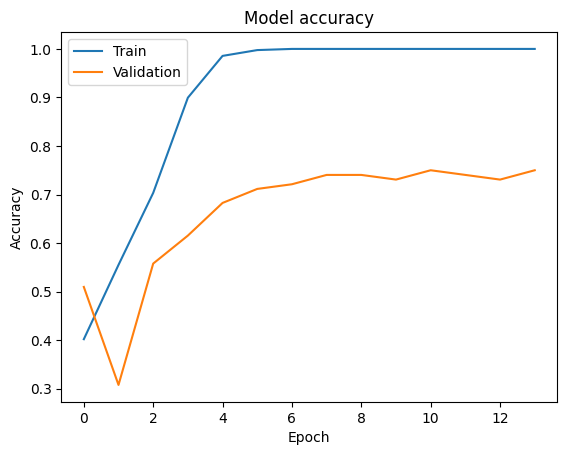

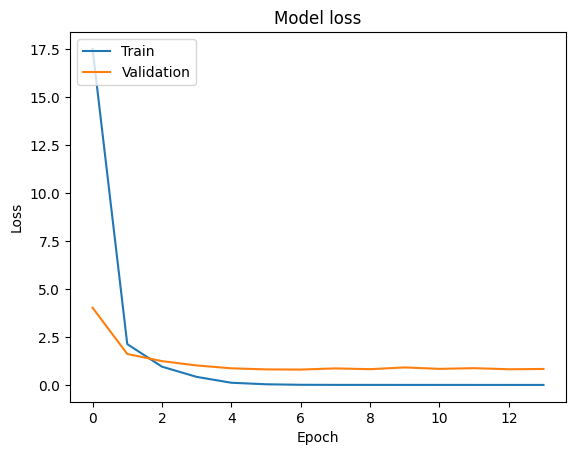

In [ ]:
plot_metrics(history)

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    plt.figure(figsize = (6,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    cm = np.round(cm,2)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

Test Loss: 0.8319602608680725
Test Accuracy: 0.75
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 734ms/step


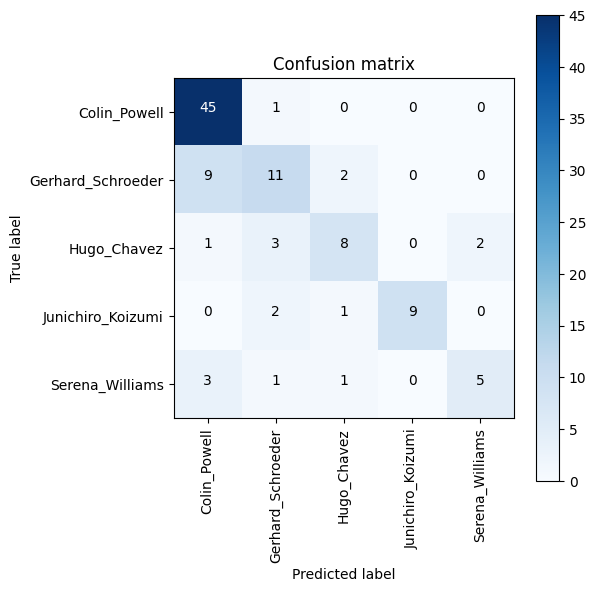

                   precision    recall  f1-score   support

     Colin_Powell       0.78      0.98      0.87        46
Gerhard_Schroeder       0.61      0.50      0.55        22
      Hugo_Chavez       0.67      0.57      0.62        14
Junichiro_Koizumi       1.00      0.75      0.86        12
  Serena_Williams       0.71      0.50      0.59        10

         accuracy                           0.75       104
        macro avg       0.75      0.66      0.70       104
     weighted avg       0.75      0.75      0.74       104



In [ ]:
def evaluate_model(model, X_test, y_test, test_labels):
    # Evaluate on test set
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print('Test Loss:', loss)
    print('Test Accuracy:', accuracy)

    # Confusion matrix
    predictions = model.predict(X_test)
    y_pred = np.argmax(predictions, axis=1)
    confusion_mtx = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
    plot_confusion_matrix(confusion_mtx, classes=list(test_labels.values()), normalize=False)

    # Classification report
    target_names = list(test_labels.values())
    print(classification_report(np.argmax(y_test, axis=1), y_pred, target_names=target_names))

evaluate_model(model, X_test, Y_test, test_labels)

## Introducing new data

The data augmented

In [ ]:
# Introducing new data into the train set for the model

import numpy as np
New_Train = "/content/gdrive/My Drive/Masters/DA_photos/"
X_train_new, y_train_new, train_labels_new = load_data(New_Train, IMG_SIZE)

# Combine the new data with the existing training data
X_train_combined = np.concatenate((X_train, X_train_new), axis=0)
y_train_combined = np.concatenate((y_train, y_train_new), axis=0)

# Update the labels if necessary
train_labels.update(train_labels_new)

100%|██████████| 5/5 [00:26<00:00,  5.39s/it]


80 images loaded from /content/gdrive/My Drive/Masters/DA_photos/ directory.


In [ ]:
Y_train_combined = to_categorical(y_train_combined, num_classes=len(train_labels))
Y_train_combined.shape

(498, 5)

In [ ]:
# Now you can retrain the model with the combined data
history = deep_model(model, X_train_combined, Y_train_combined, X_test, Y_test, epochs=14, batch_size=32) #runtime < 20 mins

Epoch 1/14
 16/288 ━━━━━━━━━━━━━━━━━━━━ 12:38 3s/step - accuracy: 0.9680 - loss: 0.2378

/usr/lib/python3.10/contextlib.py:153: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.



288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 156ms/step - accuracy: 0.9603 - loss: 0.2585 - val_accuracy: 0.6635 - val_loss: 1.0863
Epoch 2/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 83s 156ms/step - accuracy: 0.9682 - loss: 0.1687 - val_accuracy: 0.7115 - val_loss: 0.8715
Epoch 3/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 81s 158ms/step - accuracy: 0.9959 - loss: 0.0233 - val_accuracy: 0.7404 - val_loss: 1.0292
Epoch 4/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 83s 159ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 0.7115 - val_loss: 1.1208
Epoch 5/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 84s 168ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.7981 - val_loss: 0.8293
Epoch 6/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 80s 156ms/step - accuracy: 1.0000 - loss: 5.6428e-04 - val_accuracy: 0.8077 - val_loss: 0.8150
Epoch 7/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 47s 152ms/step - accuracy: 1.0000 - loss: 3.0230e-04 - val_accuracy: 0.7981 - val_loss: 0.8705
Epoch 8/14
288/288 ━━━━━━━━━━━━━━━━━━━━ 86s 167ms/step - accuracy: 1.0000 - loss: 2.27

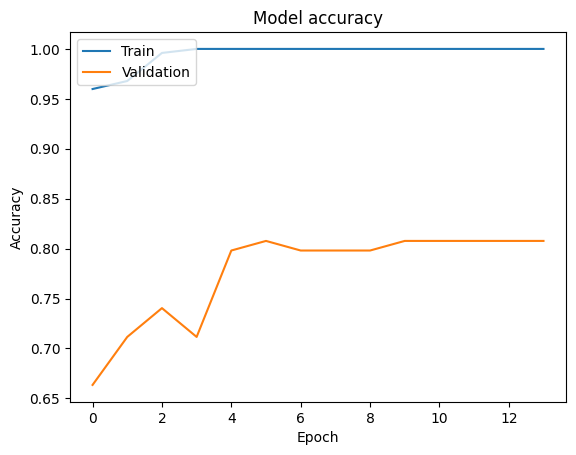

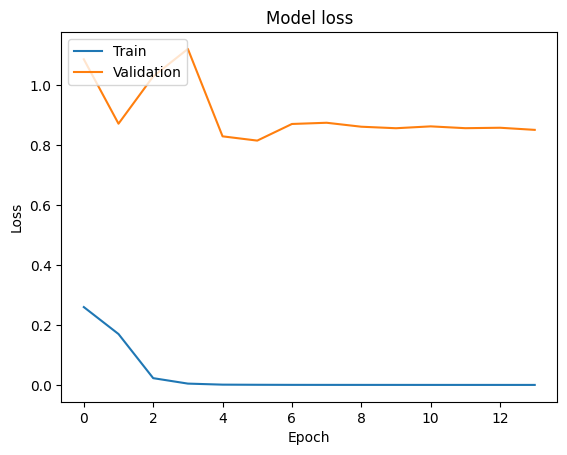

In [ ]:
plot_metrics(history)

Test Loss: 0.8508504033088684
Test Accuracy: 0.807692289352417
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 670ms/step


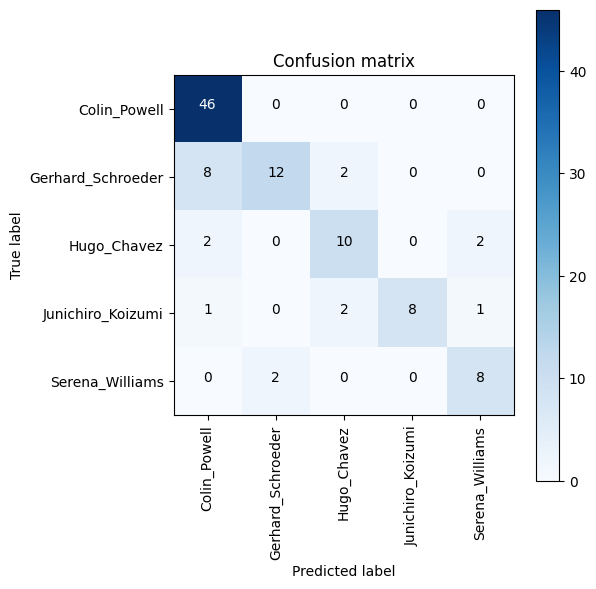

                   precision    recall  f1-score   support

     Colin_Powell       0.81      1.00      0.89        46
Gerhard_Schroeder       0.86      0.55      0.67        22
      Hugo_Chavez       0.71      0.71      0.71        14
Junichiro_Koizumi       1.00      0.67      0.80        12
  Serena_Williams       0.73      0.80      0.76        10

         accuracy                           0.81       104
        macro avg       0.82      0.75      0.77       104
     weighted avg       0.82      0.81      0.80       104



In [ ]:
def evaluate_model(model, X_test, y_test, test_labels):
    # Evaluate on test set
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print('Test Loss:', loss)
    print('Test Accuracy:', accuracy)

    # Confusion matrix
    predictions = model.predict(X_test)
    y_pred = np.argmax(predictions, axis=1)
    confusion_mtx = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
    plot_confusion_matrix(confusion_mtx, classes=list(test_labels.values()), normalize=False)

    # Classification report
    target_names = list(test_labels.values())
    print(classification_report(np.argmax(y_test, axis=1), y_pred, target_names=target_names))

evaluate_model(model, X_test, Y_test, test_labels)

# Multi-task Cascaded Convolutional Networks (MTCNN)

Using a more sophisticated model like ResNet, to a pre-trained network so we can have a better performance.

In [ ]:
#Labelled faces in the wild dataset (Kaggle has this dataset)
ALL_NAMES = "/content/gdrive/My Drive/Masters/lfw_allnames.csv"
IMAGES_SRC = "/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled"
PEOPLE = "/content/gdrive/My Drive/Masters/people.csv"
PEOPLE_TEST = "/content/gdrive/My Drive/Masters/peopleDevTest.csv"
PEOPLE_TRAIN = "/content/gdrive/My Drive/Masters/peopleDevTrain.csv"
README = "/content/gdrive/My Drive/Masters/lfw_readme.csv"
WORK_DIR = "/content/gdrive/My Drive/Masters/working/"

os.listdir('/content/gdrive/My Drive/Masters')

# Set up the transformations
trans = transforms.Compose([
    np.float32,
    transforms.ToTensor(),
    fixed_image_standardization
])

In [ ]:
from google.cloud import storage
storage_client = storage.Client(project='face-recognition')

# Set the device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Running on device: {}'.format(device))

# Load pretrained resnet model
resnet = InceptionResnetV1(
    classify=False,
    pretrained='vggface2'
).to(device)

Running on device: cpu


  0%|          | 0.00/107M [00:00<?, ?B/s]

In [ ]:
#orignal code
# Loop over images, compute features, save them into an array
df_names = pd.read_csv(ALL_NAMES)
min_faces_per_person = 52
max_faces_per_person = 5
names = ['Colin_Powell', 'Gerhard_Schroeder', 'Hugo_Chavez', 'Junichiro_Koizumi', 'Serena_Williams']

print(names)
X = [] # images
Y = [] # labels
Z = [] # embeddings

resnet.eval()
for name in names:
    dir_path = os.path.join(IMAGES_SRC, name)
    list_images_name = os.listdir(dir_path)
    list_images_name = list_images_name[: max_faces_per_person]
    for image_name in list_images_name:
        image_path = os.path.join(dir_path, image_name)
        img_rgb = plt.imread(image_path)
        x_ = trans(img_rgb)
        x_ = x_.unsqueeze(0).to(device)
        z_ = resnet(x_).to('cpu').detach().numpy()
        X.append(img_rgb)
        Y.append(name)
        Z.append(z_.squeeze(0))
    print(f"Class: {name}, number of samples: {len(list_images_name)}.")
X = np.asarray(X)
Y = np.asarray(Y)
Z = np.asarray(Z)

print(X.shape, Y.shape, Z.shape)

['Colin_Powell', 'Gerhard_Schroeder', 'Hugo_Chavez', 'Junichiro_Koizumi', 'Serena_Williams']
Class: Colin_Powell, number of samples: 5.
Class: Gerhard_Schroeder, number of samples: 5.
Class: Hugo_Chavez, number of samples: 5.
Class: Junichiro_Koizumi, number of samples: 5.
Class: Serena_Williams, number of samples: 5.
(25, 250, 250, 3) (25,) (25, 512)


(25, 25)


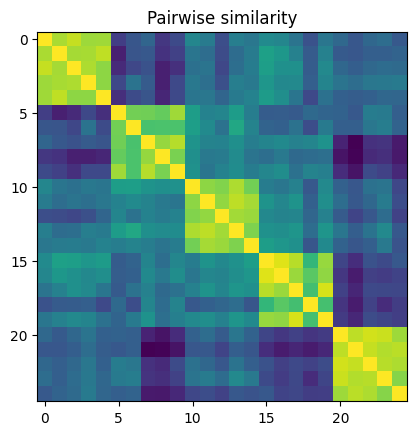

In [ ]:
# Visualize pairwise similarity
sim = np.matmul(Z, Z.transpose())
print(sim.shape)

plt.title('Pairwise similarity')
plt.imshow(sim)
plt.show()

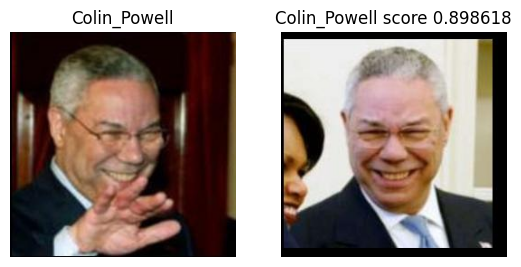

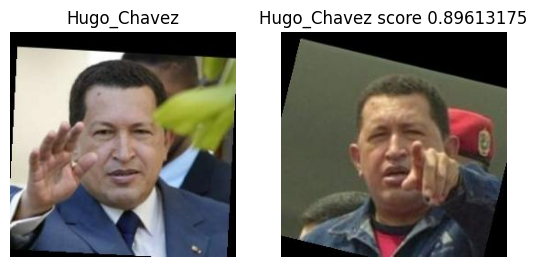

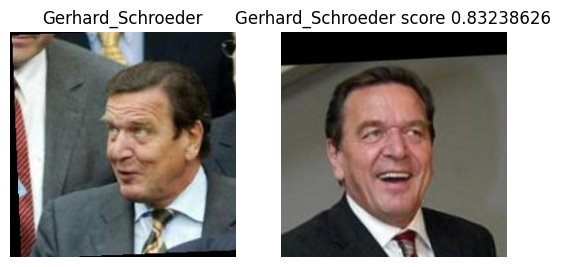

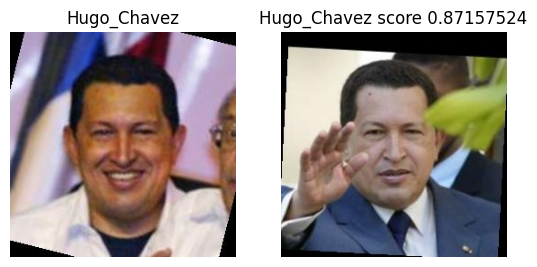

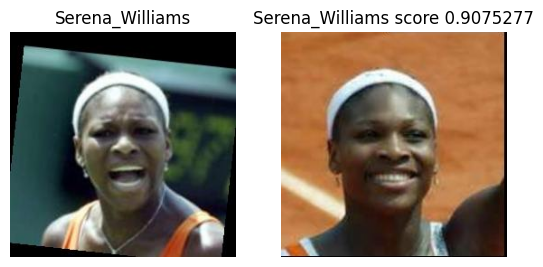

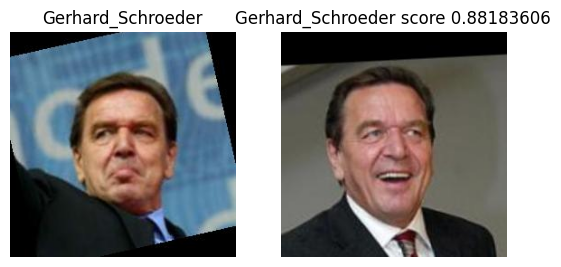

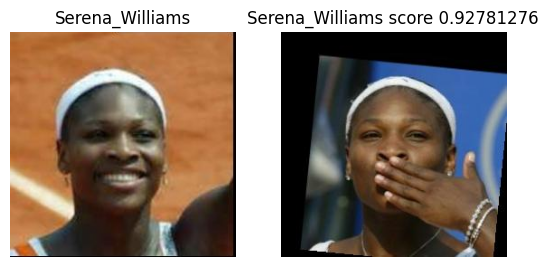

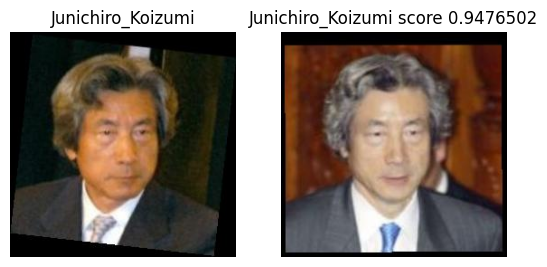

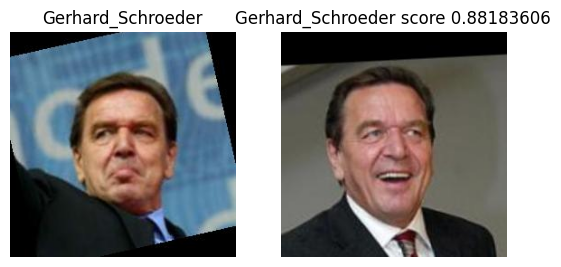

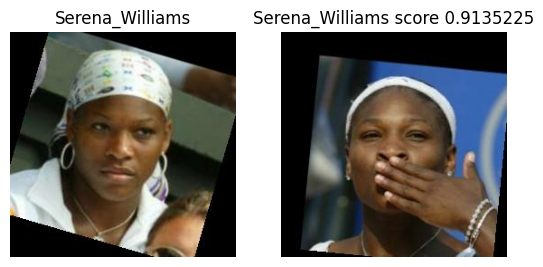

In [ ]:
from PIL import Image as im
max_to_show = 10
max_images = np.shape(sim)[0]

for i in range(max_to_show):
    fig, axs = plt.subplots(1, 2)
    id = np.random.randint(max_images)
    axs[0].imshow(X[id,:,:,:])
    axs[0].set_title(Y[id])
    axs[0].axis("off")
    s = sim[id,:]
    s[id] = -100
    matchid = np.argmax(s)
    axs[1].imshow(X[matchid,:,:,:])
    axs[1].set_title(Y[matchid] + " score " + str(s[matchid]))
    axs[1].axis("off")
    plt.show()

## Optimising the Code

We disabled the gradient calculations for inference, as well as moved the CPU after inference

In [ ]:
import time

resnet = InceptionResnetV1(
    classify=False,
    pretrained='vggface2'
).to(device)
resnet.eval()

ALL_NAMES = "/content/gdrive/My Drive/Masters/lfw_allnames.csv"
IMAGES_SRC = "/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled"
PEOPLE = "/content/gdrive/My Drive/Masters/people.csv"
PEOPLE_TEST = "/content/gdrive/My Drive/Masters/peopleDevTest.csv"
PEOPLE_TRAIN = "/content/gdrive/My Drive/Masters/peopleDevTrain.csv"
README = "/content/gdrive/My Drive/Masters/lfw_readme.csv"
WORK_DIR = "/content/gdrive/My Drive/Masters/working/"

os.listdir('/content/gdrive/My Drive/Masters')

# Set up the transformations
trans = transforms.Compose([
    np.float32,
    transforms.ToTensor(),
    fixed_image_standardization
])

In [ ]:
# Loop over images, compute features, save them into an array
df_names = pd.read_csv(ALL_NAMES)
min_faces_per_person = 50
max_faces_per_person = 50
names = ['Colin_Powell', 'Gerhard_Schroeder', 'Hugo_Chavez', 'Junichiro_Koizumi', 'Serena_Williams']

print(names)
X = []
Y = []
Z = []

['Colin_Powell', 'Gerhard_Schroeder', 'Hugo_Chavez', 'Junichiro_Koizumi', 'Serena_Williams']


In [ ]:
start_time = time.time()

with torch.no_grad(): # Disable gradient calculations for inference
    for name in names:
        dir_path = os.path.join(IMAGES_SRC, name)
        list_images_name = os.listdir(dir_path)
        list_images_name = list_images_name[: max_faces_per_person]
        for image_name in list_images_name:
            image_path = os.path.join(dir_path, image_name)
            img_rgb = plt.imread(image_path)
            x_ = trans(img_rgb)
            x_ = x_.unsqueeze(0).to(device)
            z_ = resnet(x_).cpu().numpy() # Move to CPU after inference
            X.append(img_rgb)
            Y.append(name)
            Z.append(z_.squeeze(0))
        print(f"Class: {name}, number of samples: {len(list_images_name)}.")

X = np.asarray(X)
Y = np.asarray(Y)
Z = np.asarray(Z)

print(X.shape, Y.shape, Z.shape)

end_time = time.time()
print("Embedding extraction time:", end_time - start_time)

Class: Colin_Powell, number of samples: 50.
Class: Gerhard_Schroeder, number of samples: 50.
Class: Hugo_Chavez, number of samples: 50.
Class: Junichiro_Koizumi, number of samples: 50.
Class: Serena_Williams, number of samples: 50.
(250, 250, 250, 3) (250,) (250, 512)
Embedding extraction time: 104.5530092716217


(250, 250)


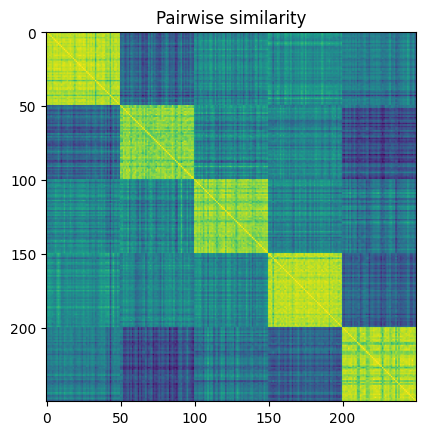

In [ ]:
# Visualize pairwise similarity
start_time = time.time()
sim = np.matmul(Z, Z.transpose())
print(sim.shape)

plt.title('Pairwise similarity')
plt.imshow(sim)
plt.show()

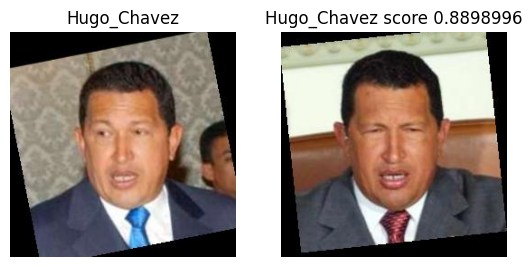

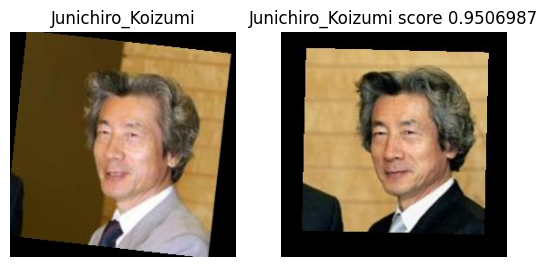

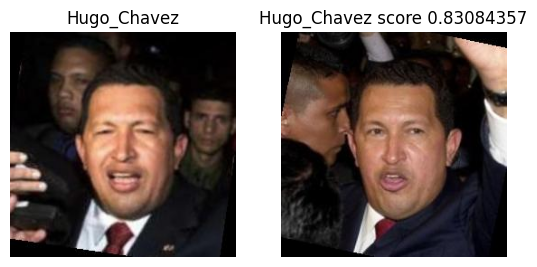

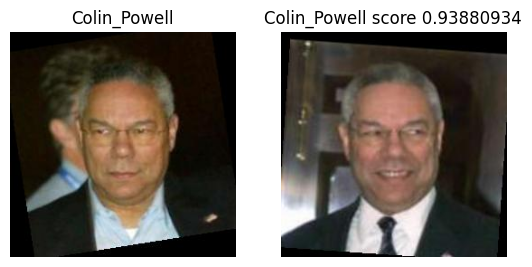

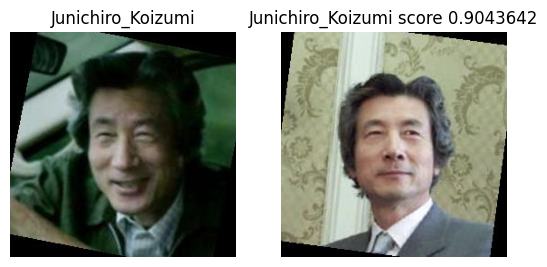

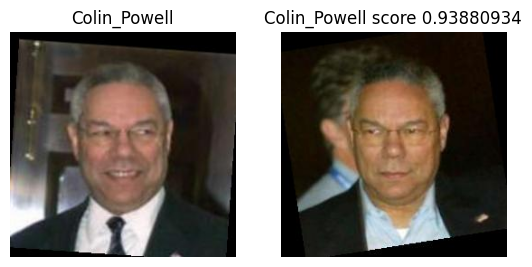

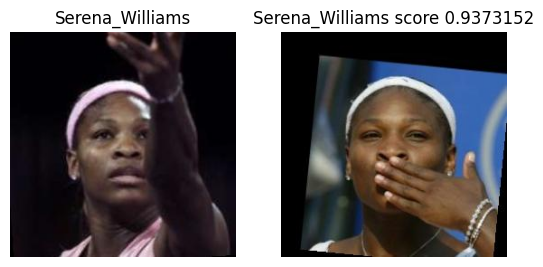

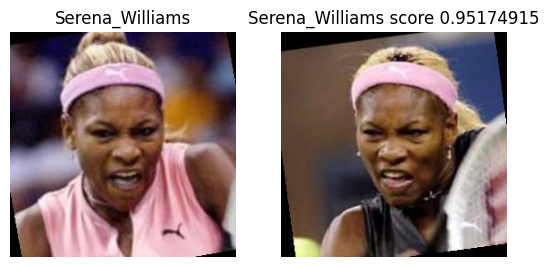

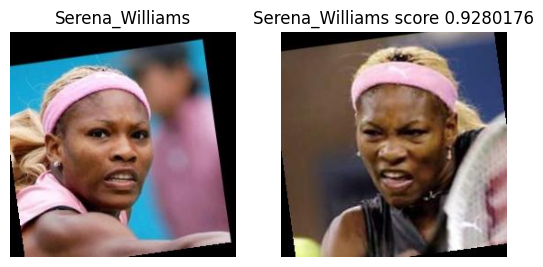

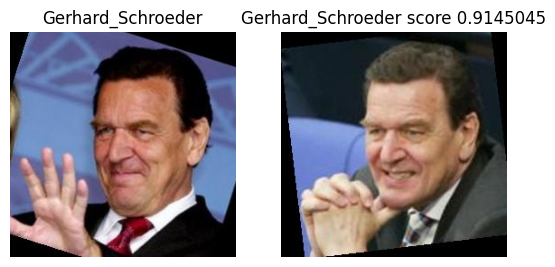

In [ ]:
max_to_show = 10
max_images = np.shape(sim)[0]

for i in range(max_to_show):
    fig, axs = plt.subplots(1, 2)
    id = np.random.randint(max_images)
    axs[0].imshow(X[id,:,:,:])
    axs[0].set_title(Y[id])
    axs[0].axis("off")
    s = sim[id,:]
    s[id] = -100
    matchid = np.argmax(s)
    axs[1].imshow(X[matchid,:,:,:])
    axs[1].set_title(Y[matchid] + " score " + str(s[matchid]))
    axs[1].axis("off")
    plt.show()


## Using Augmented Data

We tried two methods, the first one was 'Who is the person?' and the model would give the image of the most similar person based on the cosine similarity score.

The second method is to introduce the new data at the beginning of the model and see if it can get the cosine similarity scores for the images and try to recognize or verify the identity of the person.

### Method 1

Most similar face: Hugo_Chavez
Similarity score: 0.5241947770118713


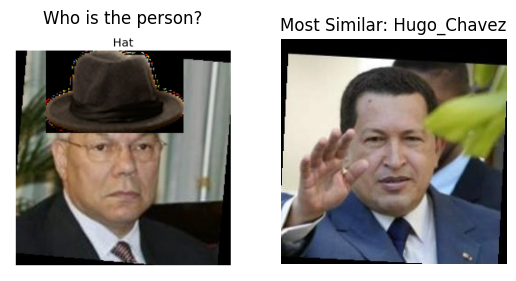

In [ ]:
# Introducing new data to the model to get the similarity score

import matplotlib.pyplot as plt
import numpy as np
# Load and preprocess the new image
# Change name to one of the following, but REMEMBER to add DA/Firstname_Secondname_DAx.jpg
#     Colin_Powell_DA1 , Colin_Powell_DA2 , ..... , Colin_Powell_DA8
#     Gerhard_Schroeder_DA1 , ..... , Gerhard_Schroeder_DA8
#     Hugo_Chavez_DA1 , ..... , Hugo_Chavez_DA8
#     Junichiro_Koizumi_DA1 , ..... , Junichiro_Koizumi_DA8
#     Serena_Williams_DA1 , ..... , Serena_Williams_DA8

new_image_path = "/content/gdrive/My Drive/Masters/DA/Colin_Powell_DA2.jpg"
img_rgb = plt.imread(new_image_path)

# Convert the image to RGB if it has an alpha channel
if img_rgb.shape[2] == 4:
    img_rgb = img_rgb[:,:,:3]  # Keep only the first 3 channels (RGB)

x_new = trans(img_rgb)
x_new = x_new.unsqueeze(0).to(device)

# Extract features for the new image
with torch.no_grad():
    z_new = resnet(x_new).to('cpu').detach().numpy()
z_new = z_new.squeeze(0)

# Calculate similarity scores
sim_new = np.dot(z_new, Z.T)

# Find the most similar face
most_similar_idx = np.argmax(sim_new)
most_similar_name = Y[most_similar_idx]
similarity_score = sim_new[most_similar_idx]

print(f"Most similar face: {most_similar_name}")
print(f"Similarity score: {similarity_score}")

# Display the new image and the most similar face
fig, axs = plt.subplots(1, 2)
axs[0].imshow(img_rgb)
axs[0].set_title("Who is the person?")
axs[0].axis("off")

axs[1].imshow(X[most_similar_idx])
axs[1].set_title(f"Most Similar: {most_similar_name}")
axs[1].axis("off")

plt.show()

Similarity score between the two images: 0.19233903288841248


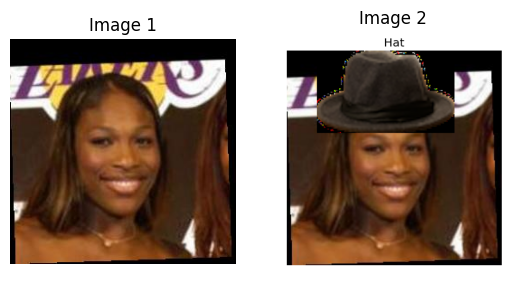

In [ ]:
# Using two photos get the a similarity score to see, is this the same person?

import matplotlib.pyplot as plt
import numpy as np
# Load and preprocess the two images
image_path1 = "/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/Serena_Williams/Serena_Williams_0024.jpg"
image_path2 = "/content/gdrive/My Drive/Masters/DA/Serena_Williams_DA3.jpg"

img_rgb1 = plt.imread(image_path1)
img_rgb2 = plt.imread(image_path2)

# Convert the images to RGB if they have an alpha channel
if img_rgb1.shape[2] == 4:
    img_rgb1 = img_rgb1[:,:,:3]
if img_rgb2.shape[2] == 4:
    img_rgb2 = img_rgb2[:,:,:3]

x_1 = trans(img_rgb1)
x_2 = trans(img_rgb2)
x_1 = x_1.unsqueeze(0).to(device)
x_2 = x_2.unsqueeze(0).to(device)

# Extract features for the images
with torch.no_grad():
    z_1 = resnet(x_1).to('cpu').detach().numpy()
    z_2 = resnet(x_2).to('cpu').detach().numpy()

z_1 = z_1.squeeze(0)
z_2 = z_2.squeeze(0)

# Calculate similarity score
similarity_score = np.dot(z_1, z_2) / (np.linalg.norm(z_1) * np.linalg.norm(z_2))

print(f"Similarity score between the two images: {similarity_score}")

# Display the two images
fig, axs = plt.subplots(1, 2)
axs[0].imshow(img_rgb1)
axs[0].set_title("Image 1")
axs[0].axis("off")

axs[1].imshow(img_rgb2)
axs[1].set_title("Image 2")
axs[1].axis("off")

plt.show()

### Method 2

In [ ]:
# Change name to one of the following, Colin_Powell, Gerhard_Schroeder, Hugo_Chavez, Junichiro_Koizumi, Serena_Williams
ALL_NAMES = "/content/gdrive/My Drive/Masters/Serena_Williams.csv"
IMAGES_SRC = "/content/gdrive/My Drive/Masters/DA_photos"
WORK_DIR = "/content/gdrive/My Drive/Masters/working/"

os.listdir('/content/gdrive/My Drive/Masters')

# Set up the transformations
trans = transforms.Compose([
    np.float32,
    transforms.ToTensor(),
    fixed_image_standardization
])

In [ ]:
!pip install opencv-python # Install OpenCV
import cv2 # Import the cv2 module

In [ ]:
# Loop over images, compute features, save them into an array
df_names = pd.read_csv(ALL_NAMES)
min_faces_per_person = 16
max_faces_per_person = 8
df_names = df_names.loc[df_names["images"] >= min_faces_per_person, :]
names = list(df_names["name"])

print(names)
X = [] # images
Y = [] # labels
Z = [] # embeddings

resnet.eval()
for name in names:
    dir_path = os.path.join(IMAGES_SRC, name)
    list_images_name = os.listdir(dir_path)
    list_images_name = list_images_name[: max_faces_per_person]
    for image_name in list_images_name:
        image_path = os.path.join(dir_path, image_name)
        img_rgb = plt.imread(image_path)

        # Convert the image to RGB if it has an alpha channel
        if img_rgb.shape[2] == 4:
            img_rgb = img_rgb[:,:,:3]  # Keep only the first 3 channels (RGB)

        # Resize images to a consistent size
        img_rgb = cv2.resize(img_rgb, (250, 250)) # Resize images to a standard size

        x_ = trans(img_rgb)
        x_ = x_.unsqueeze(0).to(device)
        z_ = resnet(x_).to('cpu').detach().numpy()
        X.append(img_rgb)
        Y.append(name)
        Z.append(z_.squeeze(0))
    print(f"Class: {name}, number of samples: {len(list_images_name)}.")
X = np.asarray(X)
Y = np.asarray(Y)
Z = np.asarray(Z)

print(X.shape, Y.shape, Z.shape)

['Serena_Williams']
Class: Serena_Williams, number of samples: 8.
(8, 250, 250, 3) (8,) (8, 512)


(8, 8)
Similarity matrix computation time: 0.005065441131591797


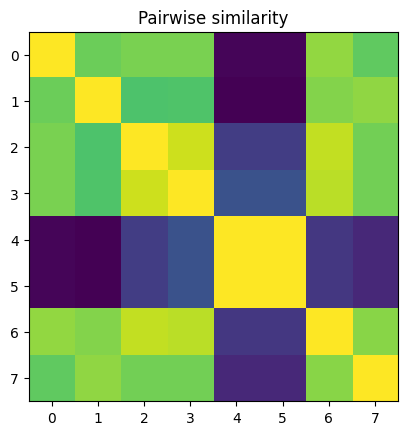

In [ ]:
# Visualize pairwise similarity
start_time = time.time()
sim = np.matmul(Z, Z.transpose())
print(sim.shape)

end_time = time.time()
print("Similarity matrix computation time:", end_time - start_time)

plt.title('Pairwise similarity')
plt.imshow(sim)
plt.show()

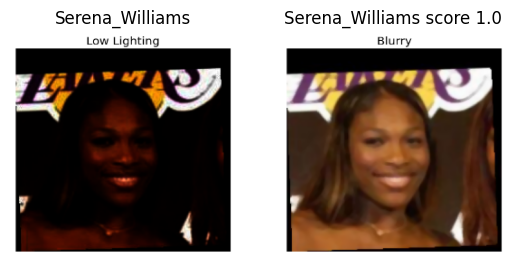

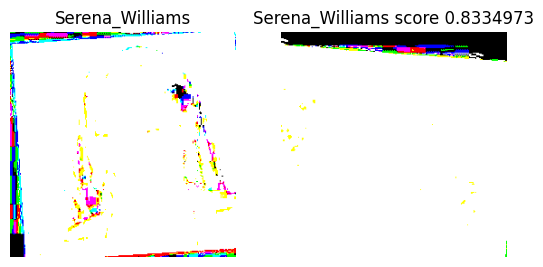

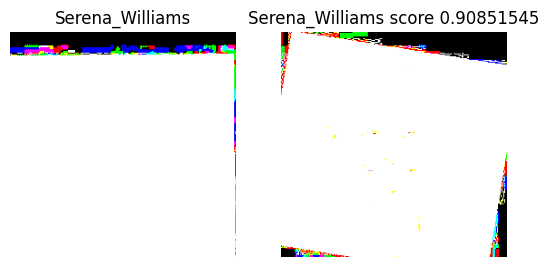

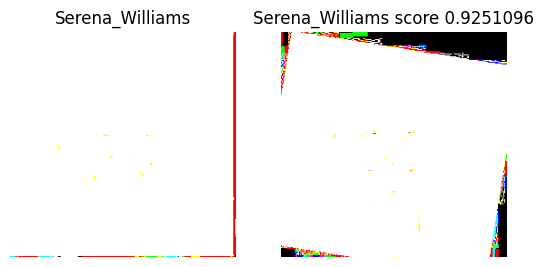

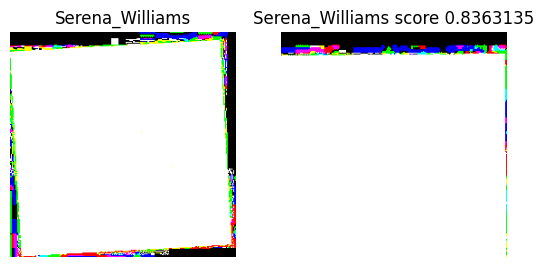

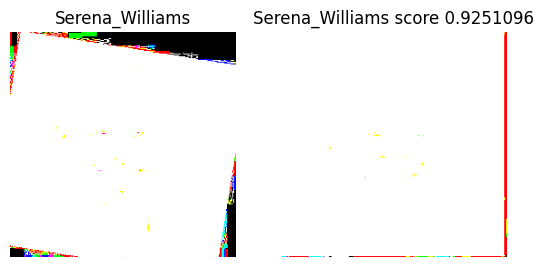

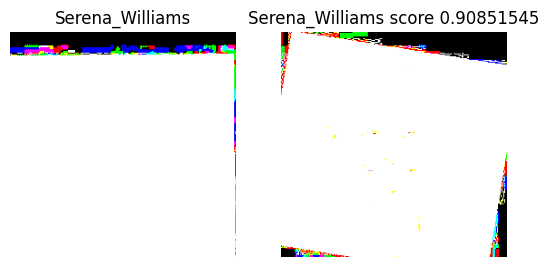

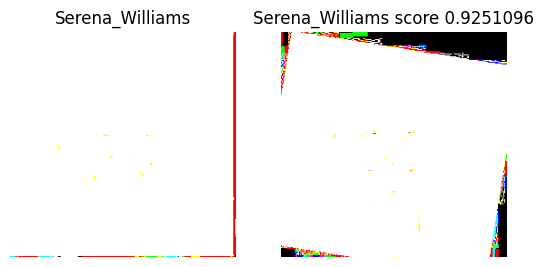

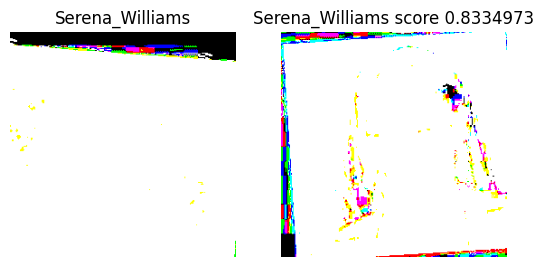

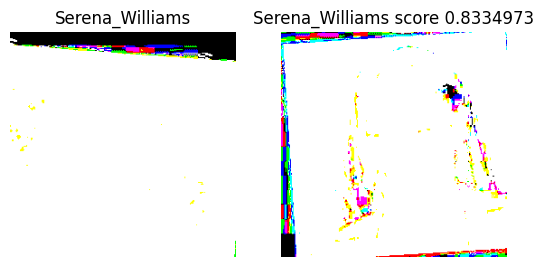

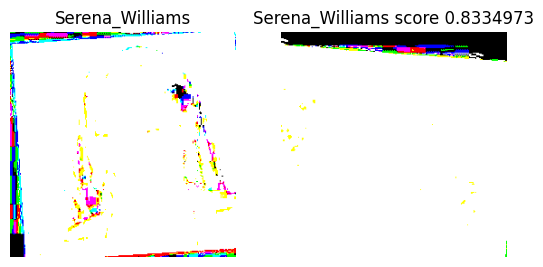

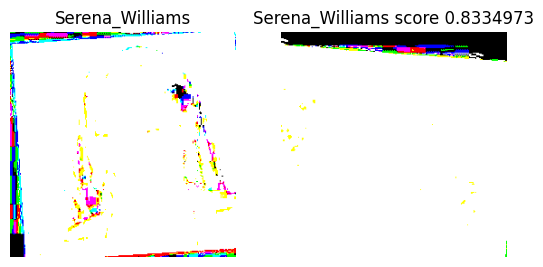

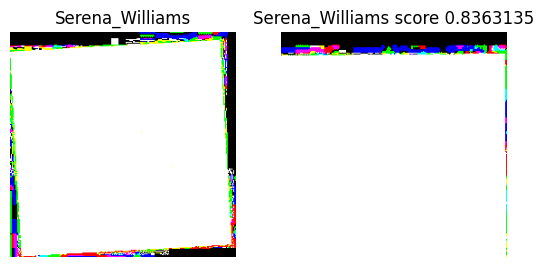

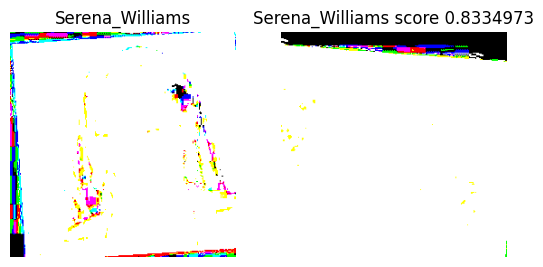

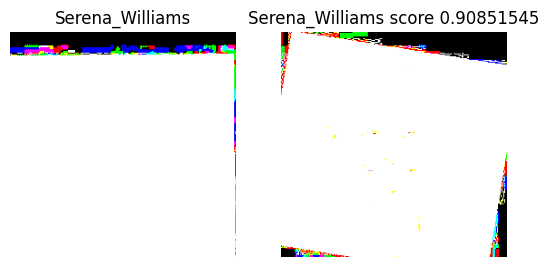

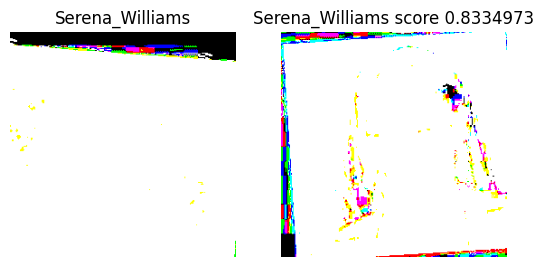

In [ ]:
max_to_show = 16
max_images = np.shape(sim)[0]

for i in range(max_to_show):
    fig, axs = plt.subplots(1, 2)
    id = np.random.randint(max_images)
    axs[0].imshow(X[id,:,:,:])
    axs[0].set_title(Y[id])
    axs[0].axis("off")
    s = sim[id,:]
    s[id] = -100
    matchid = np.argmax(s)
    axs[1].imshow(X[matchid,:,:,:])
    axs[1].set_title(Y[matchid] + " score " + str(s[matchid]))
    axs[1].axis("off")
    plt.show()

### Analysis of Similarity Scores After Haar Cascade Cropping

Similarity score between the two images: 0.47470003366470337


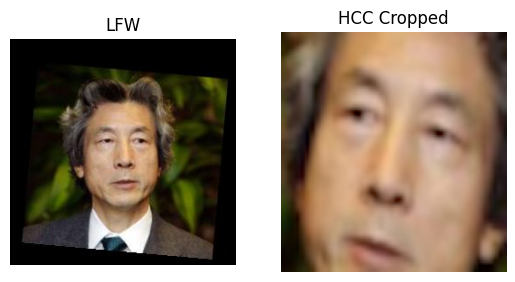

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Load and preprocess the two images
image_path1 = "/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/Junichiro_Koizumi/Junichiro_Koizumi_0047.jpg"
image_path2 = "/content/gdrive/My Drive/Masters/DA/Junichiro_Koizumi.jpeg"

img_rgb1 = plt.imread(image_path1)
img_rgb2 = plt.imread(image_path2)

# Convert the images to RGB if they have an alpha channel
if img_rgb1.shape[2] == 4:
    img_rgb1 = img_rgb1[:,:,:3]
if img_rgb2.shape[2] == 4:
    img_rgb2 = img_rgb2[:,:,:3]

x_1 = trans(img_rgb1)
x_2 = trans(img_rgb2)
x_1 = x_1.unsqueeze(0).to(device)
x_2 = x_2.unsqueeze(0).to(device)

# Extract features for the images
with torch.no_grad():
    resnet.eval() # set the model to evaluation mode
    z_1 = resnet(x_1).to('cpu').detach().numpy()
    z_2 = resnet(x_2).to('cpu').detach().numpy()

z_1 = z_1.squeeze(0)
z_2 = z_2.squeeze(0)

# Calculate similarity score
similarity_score = np.dot(z_1, z_2) / (np.linalg.norm(z_1) * np.linalg.norm(z_2))

print(f"Similarity score between the two images: {similarity_score}")

# Display the two images
fig, axs = plt.subplots(1, 2)
axs[0].imshow(img_rgb1)
axs[0].set_title("LFW")
axs[0].axis("off")

axs[1].imshow(img_rgb2)
axs[1].set_title("HCC Cropped")
axs[1].axis("off")

plt.show()